# EDA 4단계 — 변수 간 상관관계 분석

**목적**: 변수끼리 얼마나 같이 움직이는지 파악

| 분석 | 내용 |
|------|------|
| 상관계수(r) | -1 ~ +1. 1에 가까울수록 같이 오르내림, -1에 가까울수록 반대로 움직임 |
| 히트맵 | 상관계수를 색깔로 표현한 표 |
| 산점도 | 두 변수의 관계를 점으로 찍어 확인 |
| 기상x지형 | 날씨와 지형(고도·경사)이 관련 있는지 확인 |

> **왜 중요한가?**  
> 상관관계가 너무 높은 변수끼리는 같은 정보를 중복으로 담고 있어서 모델에 함께 넣으면 비효율적입니다.  
> 반대로 독립적인 변수들은 서로 다른 정보를 담아 모델에 유익합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

BASE_PATH = r'D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)'
WEATHER_PATH = BASE_PATH + '\\grid_date_master'
MONTHS = ['2025-02', '2025-03', '2025-04', '2025-05']

SCALE10_COLS = [
    'ta_mean', 'ta_max', 'hm_mean', 'hm_min',
    'td_mean', 'td_min', 'wind_ws_mean', 'wind_ws_max',
    'wind_uu_mean', 'wind_vv_mean', 'rn_day_mean', 'rn_day_max',
    'wind_wd_sin_mean', 'wind_wd_cos_mean'
]

COL_LABEL = {
    'ta_mean':'일평균기온', 'ta_max':'일최고기온',
    'hm_mean':'일평균습도', 'hm_min':'일최저습도',
    'td_mean':'일평균이슬점', 'td_min':'일최저이슬점',
    'wind_ws_mean':'일평균풍속', 'wind_ws_max':'일최대풍속',
    'wind_uu_mean':'U성분풍속', 'wind_vv_mean':'V성분풍속',
    'rn_day_mean':'일평균강수', 'rn_day_max':'일최대강수',
    'wind_wd_sin_mean':'풍향sin', 'wind_wd_cos_mean':'풍향cos'
}

print('설정 완료')

설정 완료


---
## Step 1. 샘플 데이터 준비

> 월별 10만 행씩, 총 40만 행을 무작위 추출합니다.  
> 상관관계는 10만 개 이상이면 통계적으로 충분히 신뢰할 수 있습니다.

In [2]:
frames = []
for m in MONTHS:
    df = pd.read_parquet(WEATHER_PATH, filters=[('month', '==', m)])
    s  = df[SCALE10_COLS].sample(n=100_000, random_state=42).copy()
    for col in SCALE10_COLS:
        if col not in ['wind_wd_sin_mean', 'wind_wd_cos_mean']:
            s[col] = s[col] / 10
    s['month'] = m
    frames.append(s)
    print(f'  [{m}] {len(s):,}행 샘플 추출')

df_sample = pd.concat(frames, ignore_index=True)
print(f'\n총 샘플: {len(df_sample):,}행')

  [2025-02] 100,000행 샘플 추출
  [2025-03] 100,000행 샘플 추출
  [2025-04] 100,000행 샘플 추출
  [2025-05] 100,000행 샘플 추출

총 샘플: 400,000행


---
## Step 2. 상관계수 히트맵

> 표의 각 칸 = 두 변수의 상관계수  
> - **진한 빨강** = +1 (함께 올라감)  
> - **진한 파랑** = -1 (반대로 움직임)  
> - **흰색** = 0 (관계 없음)

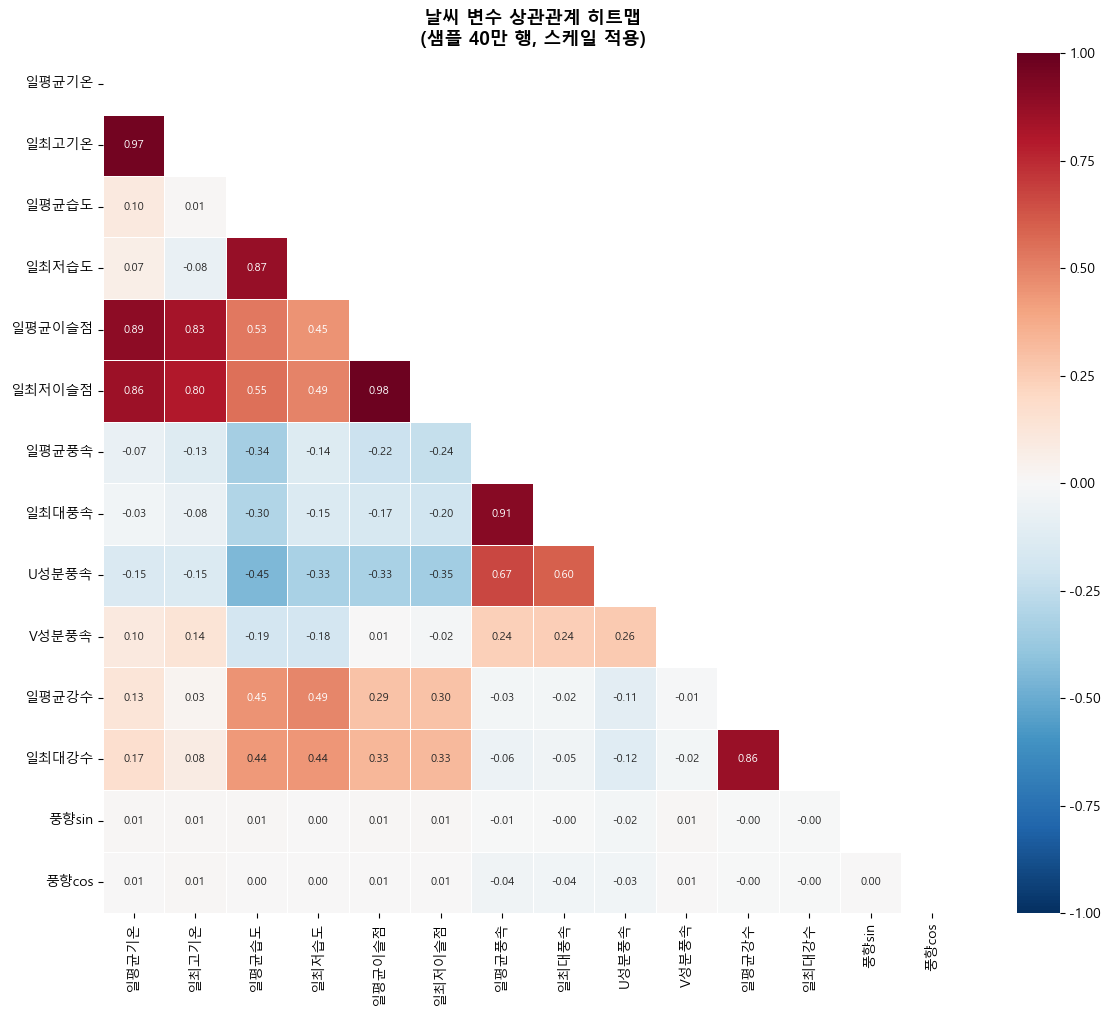

In [3]:
corr = df_sample[SCALE10_COLS].corr()
short_labels = [COL_LABEL[c] for c in SCALE10_COLS]
corr.index   = short_labels
corr.columns = short_labels

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('날씨 변수 상관관계 히트맵\n(샘플 40만 행, 스케일 적용)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_04_상관관계히트맵.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 3. 강한 상관관계 정리

> r >= 0.7 이면 **거의 같은 정보** → 모델에 둘 다 넣으면 중복  
> r >= 0.4 이면 **부분적 관련** → 참고 수준

In [4]:
corr_raw = df_sample[SCALE10_COLS].corr()

high_pairs, mid_pairs = [], []
cols = SCALE10_COLS
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = round(corr_raw.iloc[i, j], 3)
        if abs(r) >= 0.7:   high_pairs.append((cols[i], cols[j], r))
        elif abs(r) >= 0.4: mid_pairs.append((cols[i], cols[j], r))

high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
mid_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

INTERPRET = {
    ('td_mean','td_min'):           '이슬점 평균/최소: 같은 물리량',
    ('ta_mean','ta_max'):           '기온 평균/최고: 같은 물리량',
    ('wind_ws_mean','wind_ws_max'): '풍속 평균/최대: 강풍일수록 평균도 높음',
    ('ta_mean','td_mean'):          '기온 오르면 이슬점도 오름 (물리 법칙)',
    ('hm_mean','hm_min'):           '습도 평균/최소: 같은 물리량',
    ('rn_day_mean','rn_day_max'):   '강수 평균/최대: 같은 물리량',
    ('ta_mean','td_min'):           '기온 오르면 최저이슬점도 오름',
    ('ta_max','td_mean'):           '최고기온 - 이슬점 평균',
    ('ta_max','td_min'):            '최고기온 - 이슬점 최소',
}

print(f'=== 강한 상관관계 (|r| >= 0.7) — {len(high_pairs)}쌍 ===')
print(f'{"변수A":<22} {"변수B":<22} {"r":>7}  해석')
print('-' * 78)
for c1, c2, r in high_pairs:
    key = (c1, c2) if (c1, c2) in INTERPRET else (c2, c1)
    note = INTERPRET.get(key, '-')
    print(f'{c1:<22} {c2:<22} {r:>7.3f}  {note}')

print(f'\n=== 중간 상관관계 (0.4~0.7) — {len(mid_pairs)}쌍 ===')
print(f'{"변수A":<22} {"변수B":<22} {"r":>7}')
print('-' * 55)
for c1, c2, r in mid_pairs:
    print(f'{c1:<22} {c2:<22} {r:>7.3f}')

=== 강한 상관관계 (|r| >= 0.7) — 9쌍 ===
변수A                    변수B                          r  해석
------------------------------------------------------------------------------
td_mean                td_min                   0.979  이슬점 평균/최소: 같은 물리량
ta_mean                ta_max                   0.968  기온 평균/최고: 같은 물리량
wind_ws_mean           wind_ws_max              0.907  풍속 평균/최대: 강풍일수록 평균도 높음
ta_mean                td_mean                  0.894  기온 오르면 이슬점도 오름 (물리 법칙)
hm_mean                hm_min                   0.872  습도 평균/최소: 같은 물리량
rn_day_mean            rn_day_max               0.864  강수 평균/최대: 같은 물리량
ta_mean                td_min                   0.858  기온 오르면 최저이슬점도 오름
ta_max                 td_mean                  0.828  최고기온 - 이슬점 평균
ta_max                 td_min                   0.799  최고기온 - 이슬점 최소

=== 중간 상관관계 (0.4~0.7) — 11쌍 ===
변수A                    변수B                          r
-------------------------------------------------------
wind_ws_mean           wind_uu_

---
## Step 4. 핵심 산점도

> 점들이 대각선에 가까울수록 상관관계가 강합니다.  
> 월별로 색을 달리해서 **계절에 따른 관계 변화**도 확인합니다.

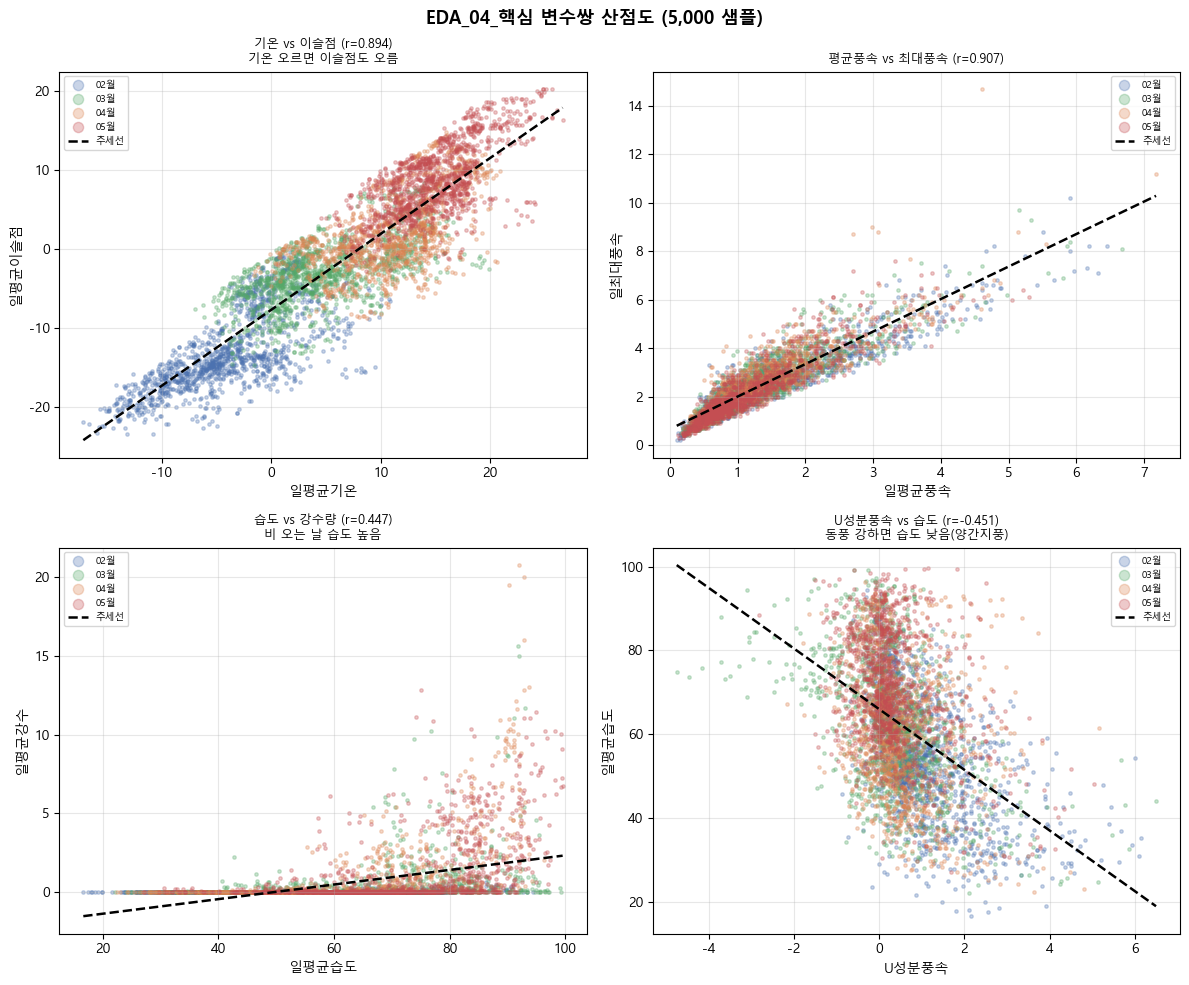

In [5]:
scatter_pairs = [
    ('ta_mean',      'td_mean',    '기온 vs 이슬점 (r=0.894)\n기온 오르면 이슬점도 오름'),
    ('wind_ws_mean', 'wind_ws_max','평균풍속 vs 최대풍속 (r=0.907)'),
    ('hm_mean',      'rn_day_mean','습도 vs 강수량 (r=0.447)\n비 오는 날 습도 높음'),
    ('wind_uu_mean', 'hm_mean',    'U성분풍속 vs 습도 (r=-0.451)\n동풍 강하면 습도 낮음(양간지풍)'),
]

plot_data = df_sample.sample(n=5_000, random_state=0)
colors_m  = {'2025-02':'#4C72B0','2025-03':'#55A868','2025-04':'#DD8452','2025-05':'#C44E52'}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (cx, cy, title) in zip(axes, scatter_pairs):
    for m, color in colors_m.items():
        sub = plot_data[plot_data['month'] == m]
        ax.scatter(sub[cx], sub[cy], alpha=0.3, s=6, color=color,
                   label=m.replace('2025-','')+'월')
    x_all = plot_data[cx].values
    y_all = plot_data[cy].values
    mask  = np.isfinite(x_all) & np.isfinite(y_all)
    z = np.polyfit(x_all[mask], y_all[mask], 1)
    xline = np.linspace(x_all[mask].min(), x_all[mask].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), 'k--', linewidth=1.8, label='추세선')
    ax.set_xlabel(COL_LABEL[cx])
    ax.set_ylabel(COL_LABEL[cy])
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, markerscale=3)
    ax.grid(True, alpha=0.3)

plt.suptitle('EDA_04_핵심 변수쌍 산점도 (5,000 샘플)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_04_산점도.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 5. 기상 × 지형 교차 상관관계

> 날씨는 지형의 영향을 받습니다.  
> **고도가 높을수록 기온이 낮다** — 이 상식이 데이터에서도 확인되는지 봅니다.

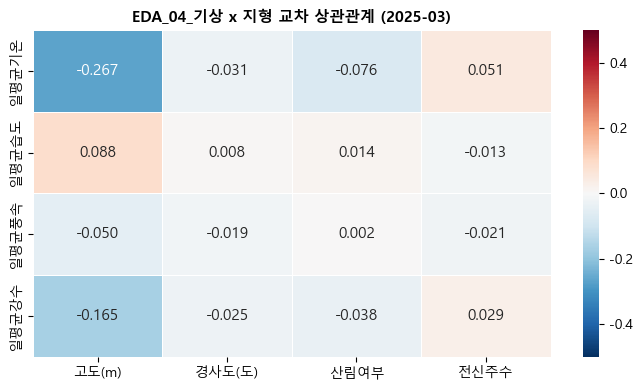

In [6]:
master = pd.read_parquet(BASE_PATH + '\\master_grid.parquet')

df_w = pd.read_parquet(WEATHER_PATH, filters=[('month','==','2025-03')])
df_w = df_w[['grid_id','ta_mean','hm_mean','wind_ws_mean','rn_day_mean']].sample(n=100_000, random_state=42)
for col in ['ta_mean','hm_mean','wind_ws_mean','rn_day_mean']:
    df_w[col] = df_w[col] / 10

df_geo = df_w.merge(master[['grid_id','elevation','slope','is_forest','pole_count']], on='grid_id')

weather_vars = ['ta_mean','hm_mean','wind_ws_mean','rn_day_mean']
terrain_vars = ['elevation','slope','is_forest','pole_count']
cross_corr = df_geo[weather_vars + terrain_vars].corr().loc[weather_vars, terrain_vars]

cross_labeled = cross_corr.copy()
cross_labeled.index   = [COL_LABEL[c] for c in weather_vars]
cross_labeled.columns = ['고도(m)','경사도(도)','산림여부','전신주수']

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    cross_labeled, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=ax, annot_kws={'size': 11}
)
ax.set_title('EDA_04_기상 x 지형 교차 상관관계 (2025-03)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_04_기상지형교차상관.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 6. 기온 vs 고도 산점도

> 고도 100m 오를 때마다 기온이 약 0.65°C 낮아지는 게 일반적입니다 (대기 체감률).  
> 데이터에서도 이 관계가 나타나는지 시각적으로 확인합니다.

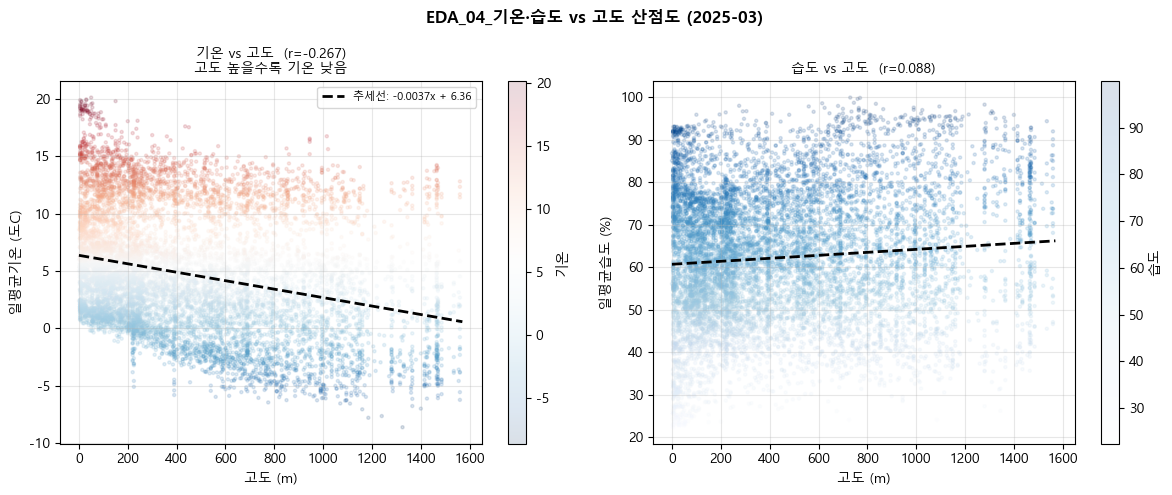

추정 체감률: 고도 100m 상승 시 기온 -0.369도C 변화
(참고) 일반적인 대기 체감률: -0.65도C / 100m
-> 공간보간 영향으로 실제보다 약하게 나타날 수 있음


In [7]:
plot_sub = df_geo.sample(n=10_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 기온 vs 고도
ax = axes[0]
sc = ax.scatter(plot_sub['elevation'], plot_sub['ta_mean'],
                alpha=0.15, s=5, c=plot_sub['ta_mean'], cmap='RdBu_r')
z = np.polyfit(df_geo['elevation'], df_geo['ta_mean'], 1)
xline = np.linspace(df_geo['elevation'].min(), df_geo['elevation'].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', linewidth=2,
        label=f'추세선: {z[0]:.4f}x + {z[1]:.2f}')
r_ta = df_geo[['elevation','ta_mean']].corr().iloc[0,1]
ax.set_xlabel('고도 (m)')
ax.set_ylabel('일평균기온 (도C)')
ax.set_title(f'기온 vs 고도  (r={r_ta:.3f})\n고도 높을수록 기온 낮음', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='기온')

# 습도 vs 고도
ax = axes[1]
sc2 = ax.scatter(plot_sub['elevation'], plot_sub['hm_mean'],
                 alpha=0.15, s=5, c=plot_sub['hm_mean'], cmap='Blues')
z2 = np.polyfit(df_geo['elevation'], df_geo['hm_mean'], 1)
ax.plot(xline, np.poly1d(z2)(xline), 'k--', linewidth=2)
r_hm = df_geo[['elevation','hm_mean']].corr().iloc[0,1]
ax.set_xlabel('고도 (m)')
ax.set_ylabel('일평균습도 (%)')
ax.set_title(f'습도 vs 고도  (r={r_hm:.3f})', fontsize=10)
ax.grid(True, alpha=0.3)
plt.colorbar(sc2, ax=ax, label='습도')

plt.suptitle('EDA_04_기온·습도 vs 고도 산점도 (2025-03)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_04_기온고도산점도.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'추정 체감률: 고도 100m 상승 시 기온 {z[0]*100:.3f}도C 변화')
print('(참고) 일반적인 대기 체감률: -0.65도C / 100m')
print('-> 공간보간 영향으로 실제보다 약하게 나타날 수 있음')

---
## Step 7. 4단계 최종 요약

In [8]:
print('=' * 65)
print('  4단계 상관관계 분석 최종 요약')
print('=' * 65)
print('''
[1] 높은 상관관계 그룹 (r >= 0.7) — 중복 정보 가능성

  기온 계열 그룹 (ta_mean, ta_max, td_mean, td_min)
  - 서로 r = 0.80 ~ 0.97  -->  거의 같이 움직임
  - 원인: 기온 오르면 이슬점도 올라가는 물리 법칙
  - 처리안: ta_mean(대표) + hm_min(건조도) 정도만 사용 검토

  평균/최대 쌍 (hm, wind_ws, rn_day)
  - 각 변수의 평균 <-> 최대 모두 r = 0.86 ~ 0.91
  - DWI 계산에 필요한 것만 유지, 중복 제거 고려

[2] 주목할 중간 상관관계 (0.4 ~ 0.7)

  - 풍속 <-> U성분(동서방향): r = 0.67
    --> 동풍 계열 바람이 우세

  - 습도 <-> 강수량: r = 0.44
    --> 비 오는 날 습도 높음 (상식과 일치)

  - U성분풍속 <-> 습도: r = -0.45
    --> 동풍 강할수록 습도 낮음
    --> 강원 양간지풍 현상과 일치! (동풍이 태백산맥 넘으면 건조해짐)
    --> 파생변수 YWI(양간지풍위험지수) 생성 근거

[3] 기상 x 지형 교차 상관관계

  - 기온 <-> 고도: r = -0.267  -->  고도 높을수록 기온 낮음
    (100m 상승 시 약 -0.2도C, 공간보간 때문에 일반 체감률보다 약함)
  - 나머지: |r| < 0.2  -->  기상 <-> 지형은 대체로 독립적
  - 지형 변수는 기상과 다른 정보를 담음 --> 모델에 함께 사용 유효

[모델 구축 시 활용 포인트]
  1. 기온 계열 중복 제거 --> ta_mean 또는 hm_min 대표 선택
  2. U성분풍속 + 습도 음의 관계 --> 양간지풍 파생변수 근거 확보
  3. 지형 변수 독립적 --> 기상과 함께 입력 시 정보 보완
''')
print('-> 다음: 전처리 마무리 (스케일 변환 + 파생변수 생성)')
print('=' * 65)

  4단계 상관관계 분석 최종 요약

[1] 높은 상관관계 그룹 (r >= 0.7) — 중복 정보 가능성

  기온 계열 그룹 (ta_mean, ta_max, td_mean, td_min)
  - 서로 r = 0.80 ~ 0.97  -->  거의 같이 움직임
  - 원인: 기온 오르면 이슬점도 올라가는 물리 법칙
  - 처리안: ta_mean(대표) + hm_min(건조도) 정도만 사용 검토

  평균/최대 쌍 (hm, wind_ws, rn_day)
  - 각 변수의 평균 <-> 최대 모두 r = 0.86 ~ 0.91
  - DWI 계산에 필요한 것만 유지, 중복 제거 고려

[2] 주목할 중간 상관관계 (0.4 ~ 0.7)

  - 풍속 <-> U성분(동서방향): r = 0.67
    --> 동풍 계열 바람이 우세

  - 습도 <-> 강수량: r = 0.44
    --> 비 오는 날 습도 높음 (상식과 일치)

  - U성분풍속 <-> 습도: r = -0.45
    --> 동풍 강할수록 습도 낮음
    --> 강원 양간지풍 현상과 일치! (동풍이 태백산맥 넘으면 건조해짐)
    --> 파생변수 YWI(양간지풍위험지수) 생성 근거

[3] 기상 x 지형 교차 상관관계

  - 기온 <-> 고도: r = -0.267  -->  고도 높을수록 기온 낮음
    (100m 상승 시 약 -0.2도C, 공간보간 때문에 일반 체감률보다 약함)
  - 나머지: |r| < 0.2  -->  기상 <-> 지형은 대체로 독립적
  - 지형 변수는 기상과 다른 정보를 담음 --> 모델에 함께 사용 유효

[모델 구축 시 활용 포인트]
  1. 기온 계열 중복 제거 --> ta_mean 또는 hm_min 대표 선택
  2. U성분풍속 + 습도 음의 관계 --> 양간지풍 파생변수 근거 확보
  3. 지형 변수 독립적 --> 기상과 함께 입력 시 정보 보완

-> 다음: 전처리 마무리 (스케일 변환 + 파생변수 생성)
